In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [63]:
from importlib import reload
import vis; reload(vis)

df = pd.read_csv('./v2_summary.csv')

ovars = ['objective', 'cost']
dvars = ['size', 'cable']

self = vis.Visualizer(
    data=df[ovars + dvars],
    data_ovars=ovars, data_dvars=dvars
)

In [125]:
X = df.set_index(['location', 'technology'])\
    .sort_index()

y = X.objective

X.drop(columns=['objective'], inplace=True)

X

capacity  duration     cost  power       size  \
location   technology                                                  
COTTONWOOD LAB           1810.0         2   896.89   1000  45.068999   
           LAB           1810.0         2   957.58    100  45.068999   
           LAB           1810.0         4  1622.89   1000  45.068999   
           LAB           1810.0         4  1723.50    100  41.770469   
           LAB           1810.0         6  2348.03   1000  21.343832   
...                         ...       ...      ...    ...        ...   
WCASCADE   VRF           1500.0         4  2599.45    100   5.703987   
           VRF           1500.0         6  3248.67   1000   0.000021   
           VRF           1500.0         6  3420.59    100   0.000010   
           VRF           1500.0         8  3652.63   1000   0.000008   
           VRF           1500.0         8  3846.21    100   0.000005   

                             cable  
location   technology               
COTTONWOOD LAB         1638.758919  
           LAB         1638.758919  
           LAB         1638.758918  
           LAB         1637.247092  
           LAB         1627.884883  
...                            ...  
WCASCADE   VRF         1343.583079  
           VRF         1340.968762  
           VRF         1340.968756  
           VRF         1340.968755  
           VRF         1340.968754  

[160 rows x 6 columns]

COTTONWOOD LAB
COTTONWOOD LFP
COTTONWOOD NMC
COTTONWOOD VRF
JOHNDAY LAB
JOHNDAY LFP
JOHNDAY NMC
JOHNDAY VRF
MOSSLAND LAB
MOSSLAND LFP
MOSSLAND NMC
MOSSLAND VRF
TESLA LAB
TESLA LFP
TESLA NMC
TESLA VRF
WCASCADE LAB
WCASCADE LFP
WCASCADE NMC
WCASCADE VRF


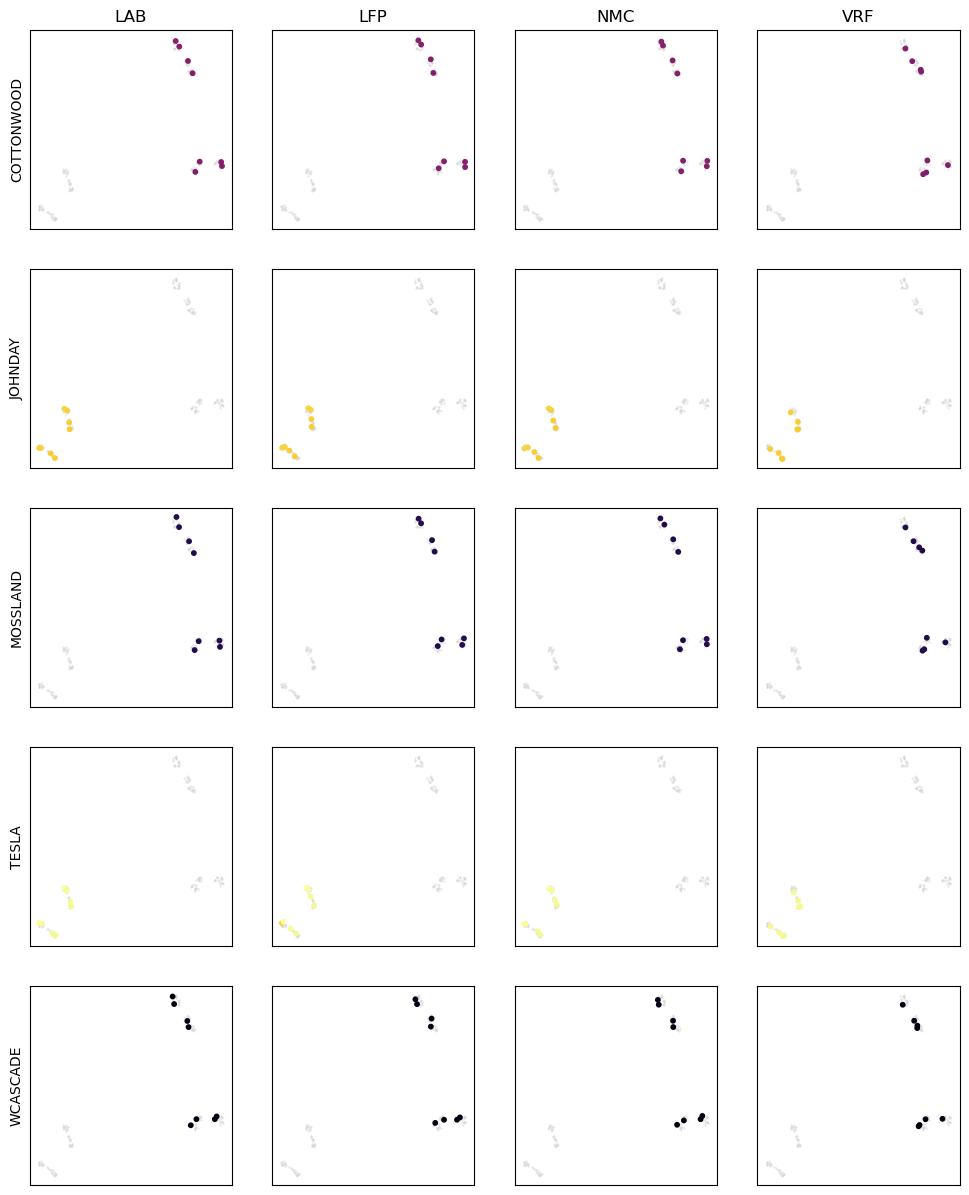

In [197]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def get_index(level):
    return {
        v: i
        for i, v in enumerate(X.index.get_level_values(level).unique())
    }

rows = get_index(0)
cols = get_index(1)

pipe = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP())
])

xy = pd.DataFrame(
    pipe.fit_transform(data),
    index=X.index
)

s = 3
plt.figure(figsize=(s*len(cols), s*len(rows)))

norm = plt.Normalize(y.min(), y.max())
cmap = plt.cm.inferno

for i, r in enumerate(rows):
    for j, c in enumerate(cols):
        ax = plt.subplot(len(rows), len(cols), i*len(cols) + j + 1)
        if (r, c) in xy.index:
            print(r, c)
            ax.scatter(*xy.values.T, s=.1, c='lightgray')
            ax.scatter(
                *xy.loc[r, c].values.T,
                s=10,
                c=cmap(norm(y.loc[r, c]))
            )

        plt.xticks([], [])
        plt.yticks([], [])
        
        if j == 0:
            plt.ylabel(r)
            
        if i == 0:
            plt.title(c)


/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden

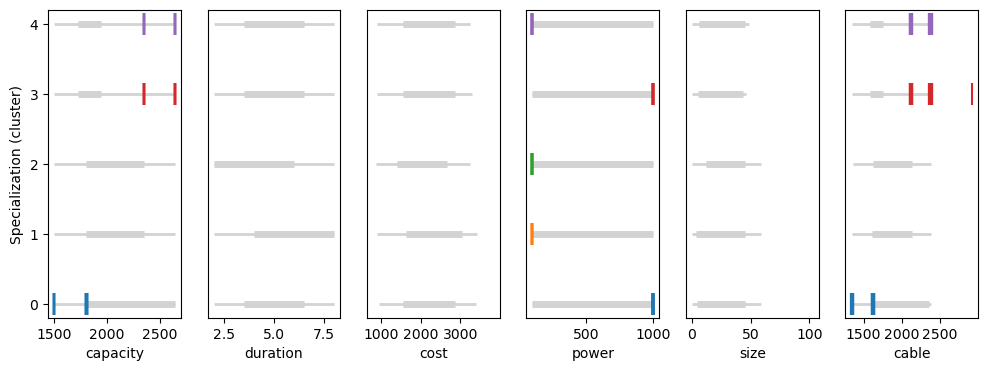

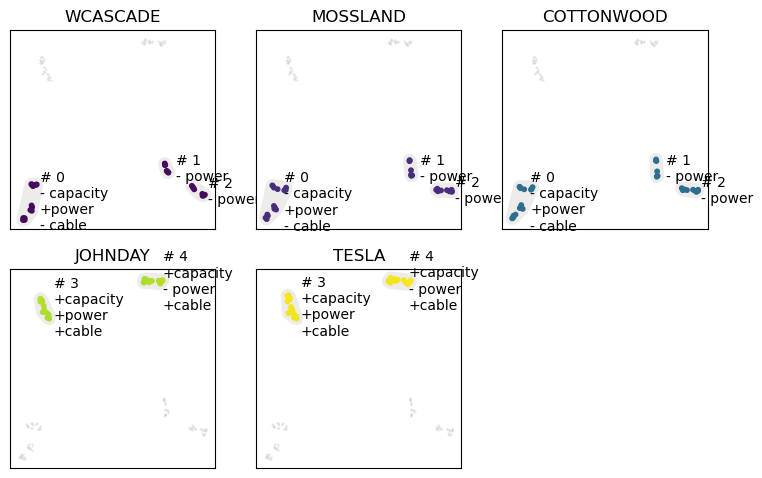

<Figure size 1200x1500 with 0 Axes>

<Figure size 600x300 with 0 Axes>

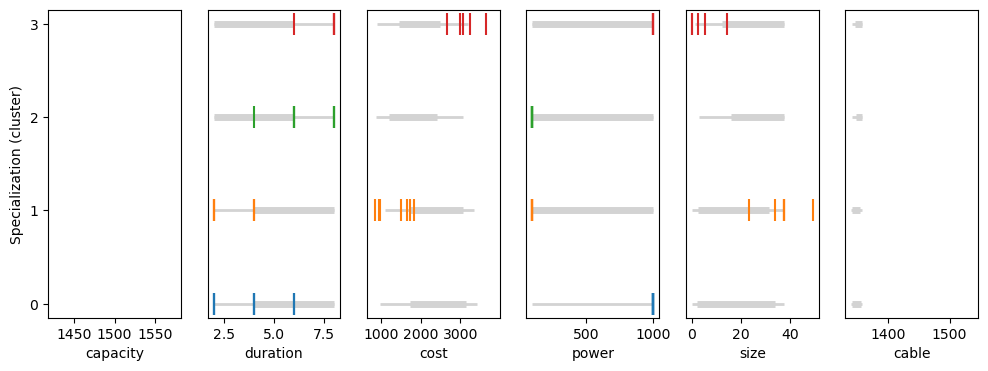

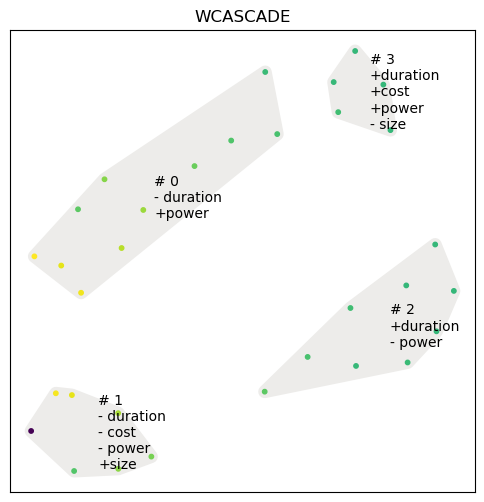

<Figure size 600x300 with 0 Axes>

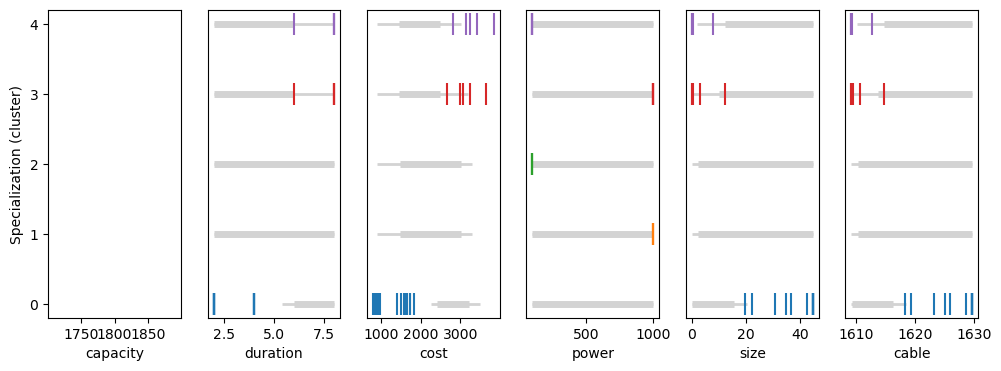

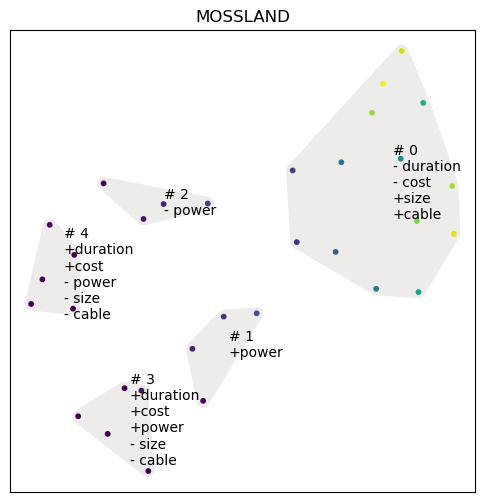

<Figure size 600x300 with 0 Axes>

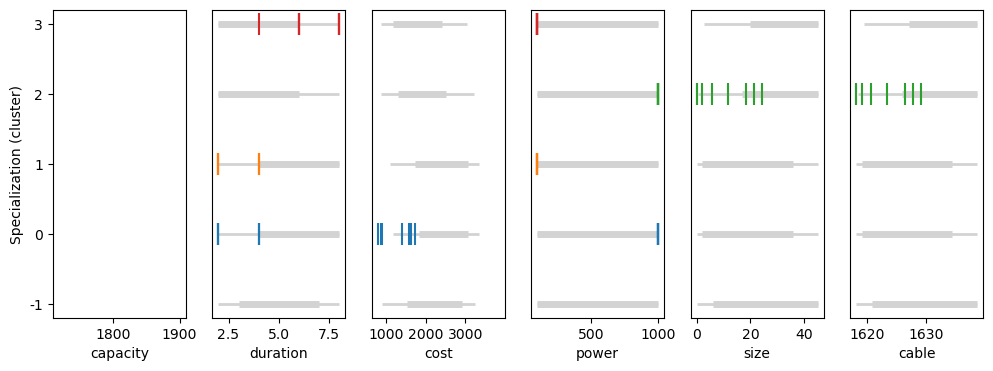

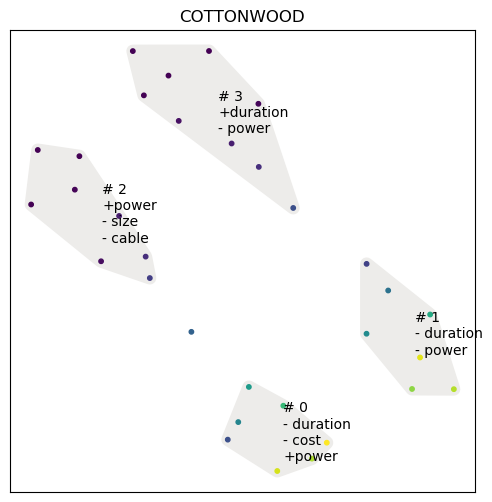

<Figure size 600x300 with 0 Axes>

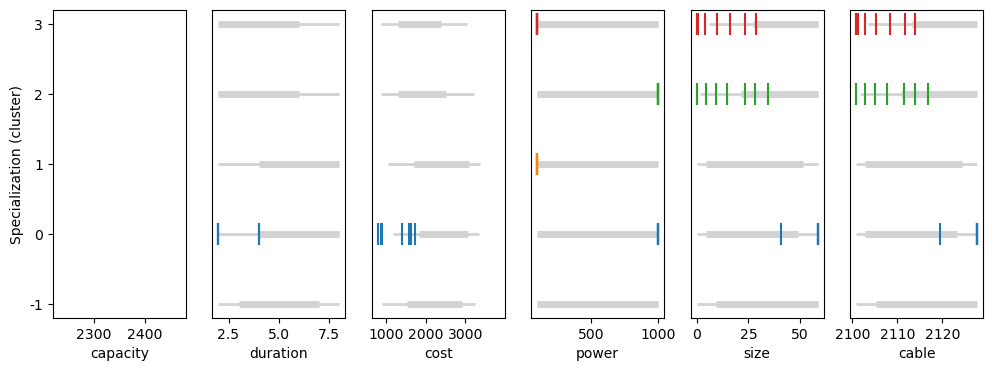

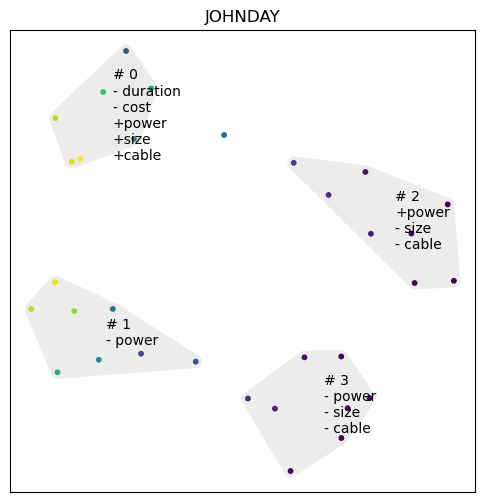

<Figure size 600x300 with 0 Axes>

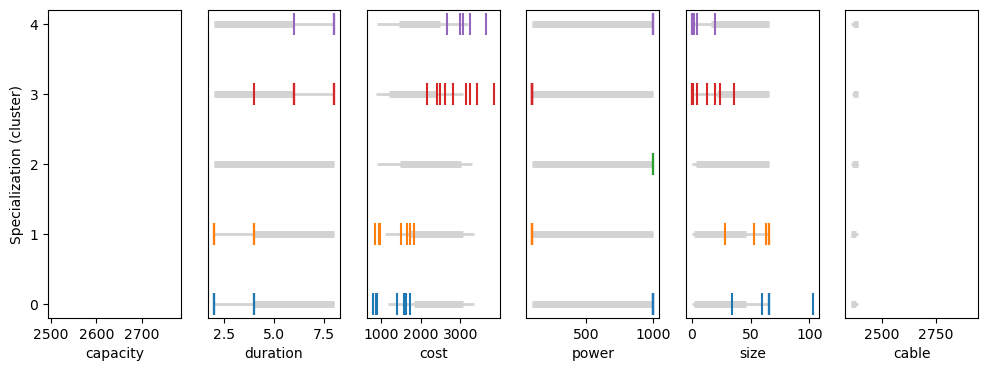

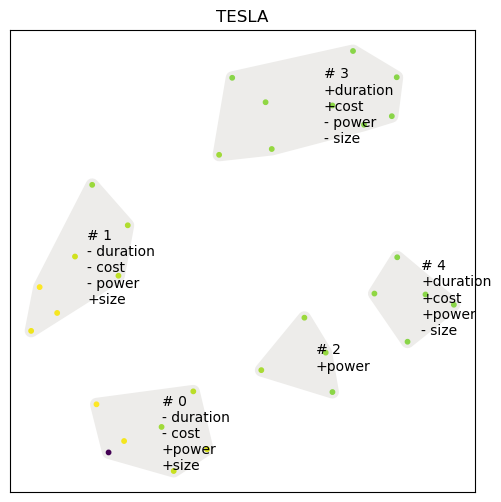

In [338]:
from sklearn.cluster import DBSCAN, HDBSCAN

reload(vis)

def draw_scatter_with_labels(xy, y_cluster, hue, coef, threshold=1.0, cmap=plt.cm.viridis, vmin=None, vmax=None, ax=None):
    ax = ax or plt.gca()

    norm = plt.Normalize(vmin, vmax)
    vis.get_cluster_hulls(xy, y_cluster, marker_color=cmap(norm(hue)), marker_size=10, with_labels=False)

    if coef is not None:
        def get_label(ser):
            names = [
                f'{"+" if np.sign(v) > 0 else "- "}{k}'
                for k, v in ser.items()
                if abs(v) > threshold
            ]
            return '\n'.join(names)
            
        labels = coef.apply(get_label, axis=1)
        centroids = xy.groupby(y_cluster).mean()

        for ci in set(y_cluster):
            if ci != -1:
                ax.annotate(
                    f'# {ci}\n{labels.loc[ci]}', centroids.loc[ci],
                    va='center',
                    xytext=(7, 0),
                    textcoords='offset points'
                )
            
def draw_faceted_umap_global(pipe, X, y, s=3, ncols=3):
    rows = y.groupby(level=0).mean().sort_values()
    nrows = len(rows)

    y_cluster = pd.Series(pipe.fit_predict(X), index=X.index)
    xy = pd.DataFrame(pipe['proj'].embedding_, index=X.index)
    
    threshold = 1.0
    coef = vis.explain_groups(
        X,
        y_cluster,
        colors=plt.cm.tab10(y_cluster), threshold=threshold, xlim=None
    )

    kwargs = dict(
        vmin=y.min(),
        vmax=y.max(),
        coef=coef
    )

    plt.figure(figsize=(s*ncols, s*nrows))
    for i, (r, v) in enumerate(rows.items()):
        ax = plt.subplot(nrows, ncols, i + 1)
        plt.title(r)
        
        ax.scatter(*xy.values.T, s=.1, c='lightgray')
        draw_scatter_with_labels(
            xy.loc[r], y_cluster.loc[r],
            hue=y.loc[r],
            ax=ax,
            **kwargs
        )

        plt.xticks([], [])
        plt.yticks([], [])

def draw_faceted_umap_local(pipe, X, y, s=3, ncols=3, threshold=.5):
    rows = y.groupby(level=0).mean().sort_values()
    nrows = len(rows)
    ncols = 2

    plt.figure(figsize=(2*s*ncols, s*nrows))
    for i, (r, v) in enumerate(rows.items()):
        Xr = X.loc[r]        
        y_cluster_r = pd.Series(pipe.fit_predict(Xr), index=Xr.index)
        xy_r = pd.DataFrame(pipe['proj'].embedding_, index=Xr.index)
        y_r = y.loc[r]
        
        plt.figure(figsize=(6, 3))
        coef = vis.explain_groups(
            Xr,
            y_cluster_r,
            colors=plt.cm.tab10(y_cluster_r),
            threshold=threshold,
            xlim=None
        ) if y_cluster_r.nunique() > 1 else None

        plt.figure(figsize=(6, 6))
        draw_scatter_with_labels(
            xy_r,
            y_cluster_r,
            hue=y_r,
            coef=coef,
            threshold=threshold
        )
        plt.title(r)
        plt.xticks([], [])
        plt.yticks([], [])



args = (
    X.reset_index('technology', drop=True),
    y.reset_index('technology', drop=True)
)

pipe1 = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP(random_state=1234567890)),
    ('clu', DBSCAN(eps=2.0))
])
draw_faceted_umap_global(pipe1, *args)

pipe2 = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP(random_state=1234567890)),
    ('clu', DBSCAN(eps=.65, min_samples=2))
])
draw_faceted_umap_local(pipe2, *args)

# add colormap

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/matrix.py:495: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  self.linkage = self.calculated_linkage
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/matrix.py:495: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  self.linkage = self.calculated_linkage


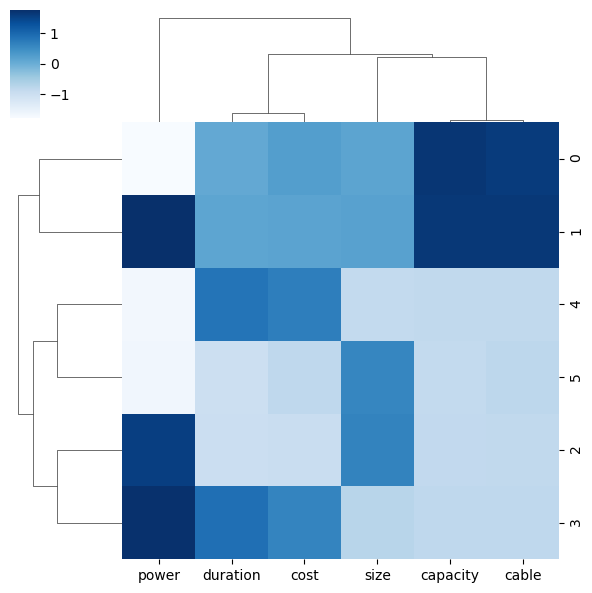

In [257]:
sns.clustermap(coef, cmap='Blues', figsize=(6, 6))

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/matrix.py:495: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  self.linkage = self.calculated_linkage
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/matrix.py:495: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  self.linkage = self.calculated_linkage


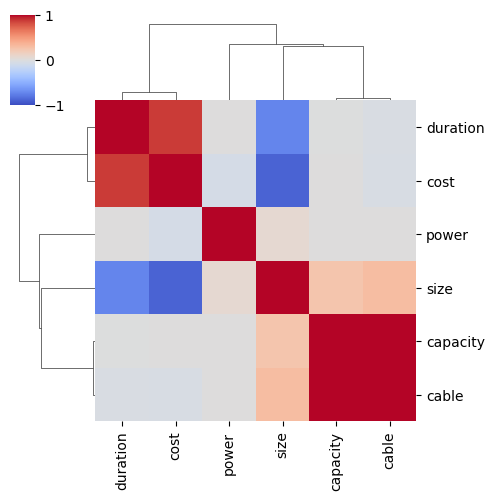

In [131]:
import seaborn as sns

C = X.corr()
sns.clustermap(C, cmap='coolwarm', vmin=-1, vmax=1, figsize=(5,5))

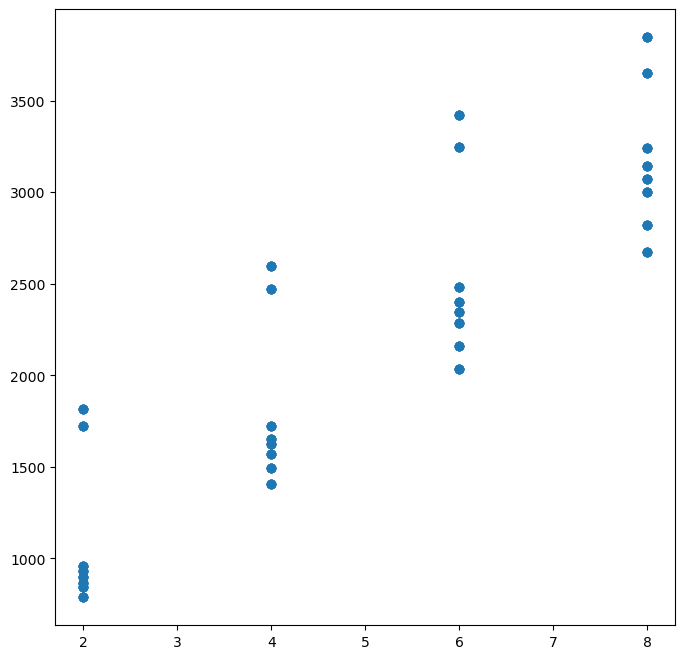

In [136]:
plt.scatter(X.duration, X.cost)

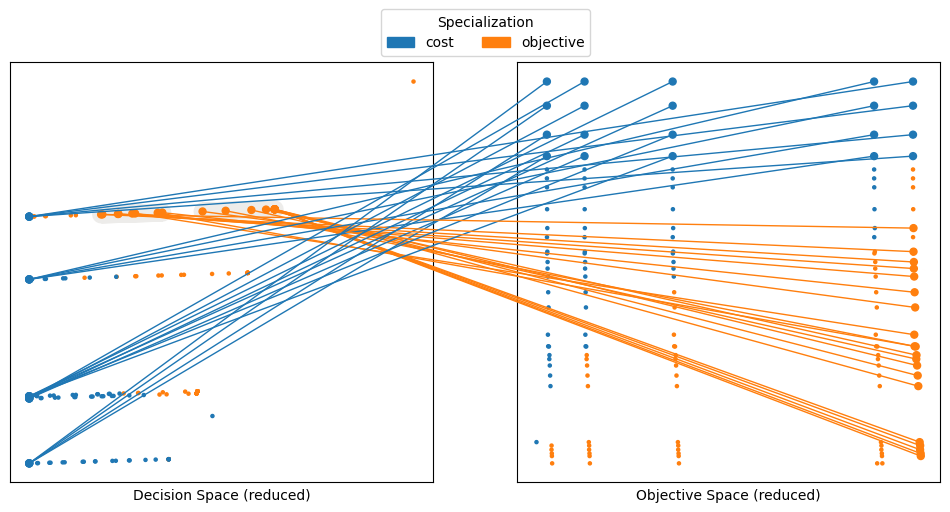

In [64]:
reload(vis)

self.show_specialization_clustering(
    left_xy=self.df[self.dvars],
    
)

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is depreca

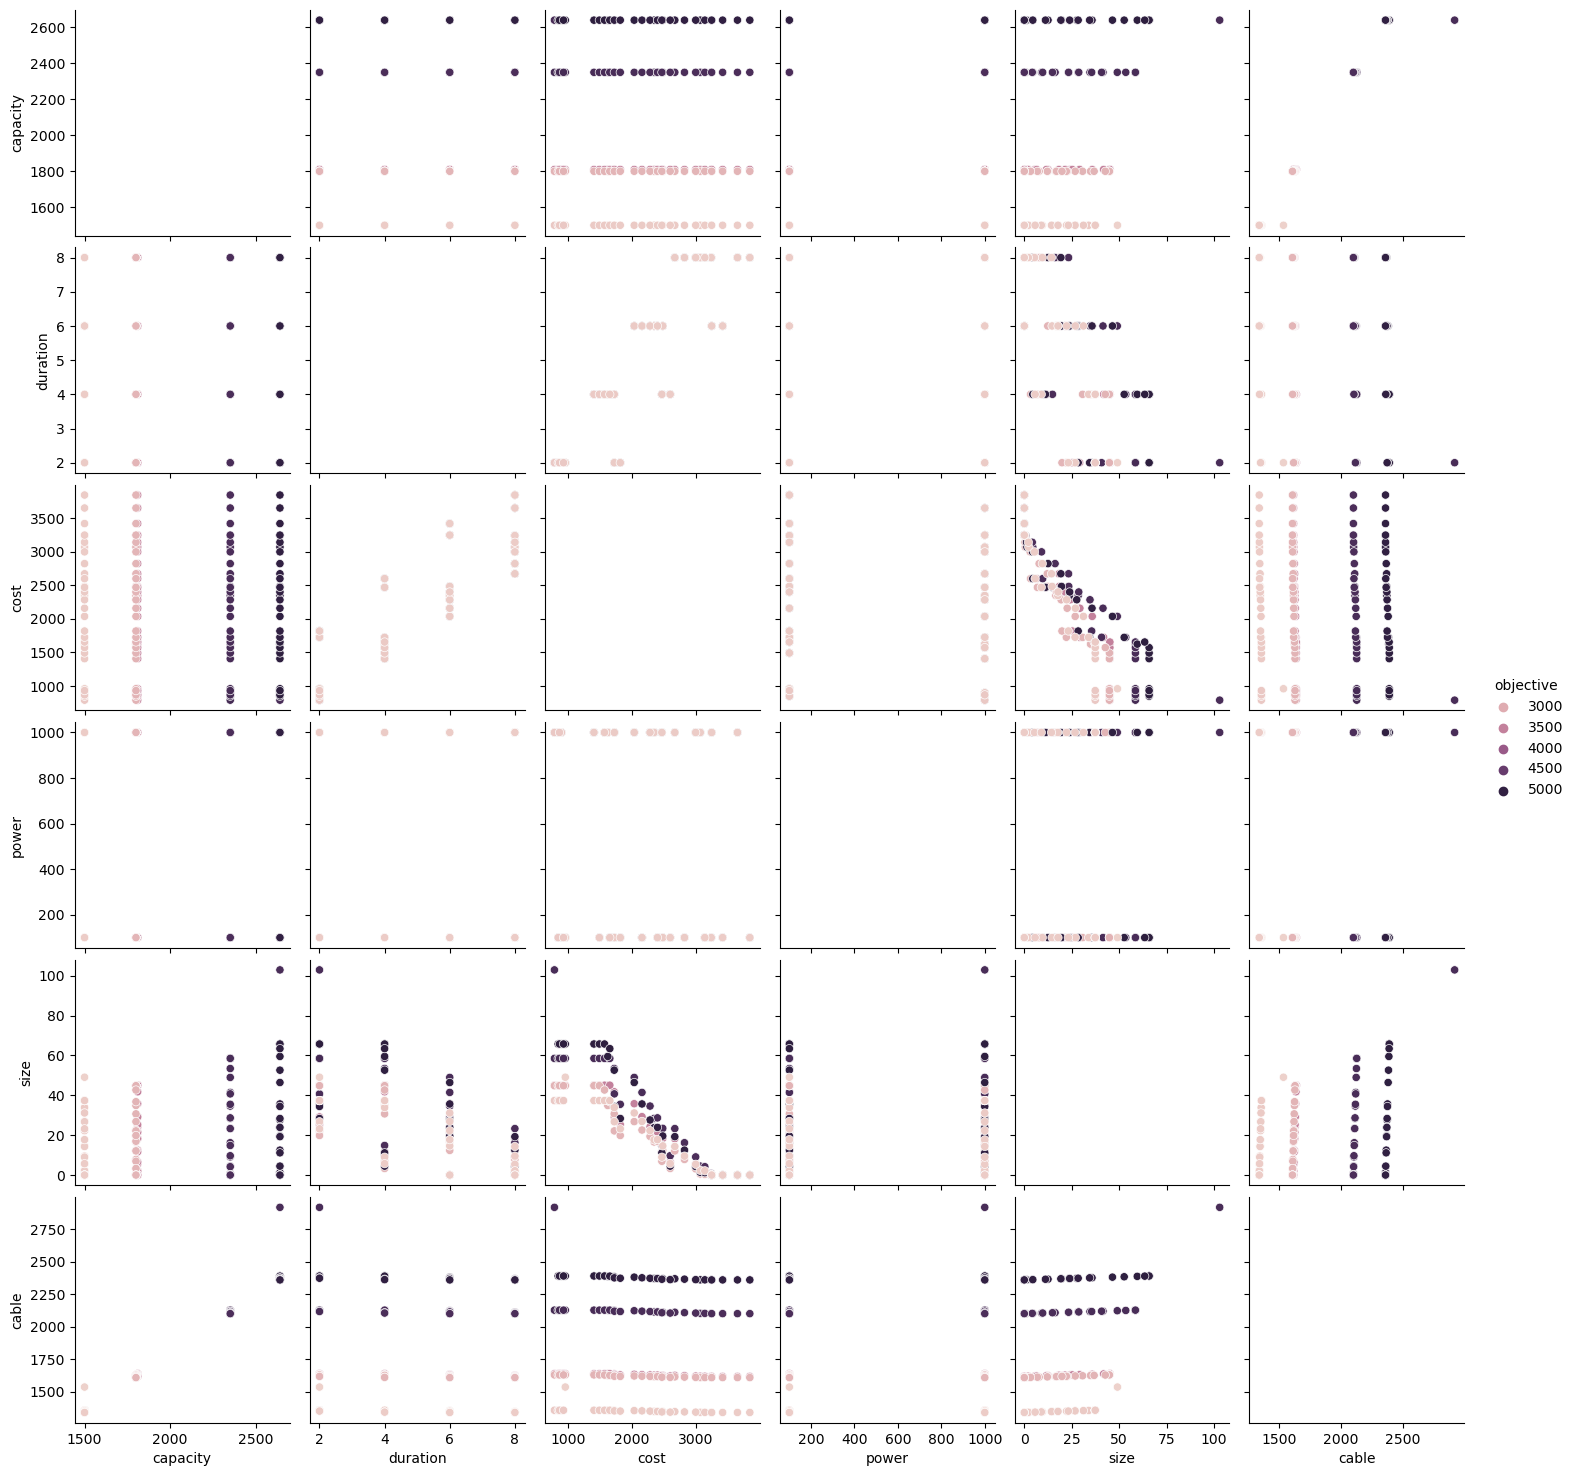

In [145]:
sns.pairplot(pd.concat((X, y), axis=1), hue='objective')

In [373]:
from scipy.spatial import Delaunay
import networkx as nx

def get_triangulation(points):
    G = nx.Graph()
    
    tri = Delaunay(points)
    for i, j, k in tri.simplices:
        G.add_edge(i, j)
        G.add_edge(j, k)
        G.add_edge(k, i)

    return G

def tradeoff_lattice(X, y):
    centroids = pd.DataFrame(X).groupby(y).mean().values
    G = get_triangulation(centroids)
    
    plt.scatter(*X.T, c=y, cmap=plt.cm.tab10, vmin=0, vmax=9, s=1)
    plt.scatter(*centroids.T, marker='o', s=200)
    nx.draw_networkx(G, pos=dict(enumerate(centroids)), edgecolors='lightgray', facecolors='none')


/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


ValueError: Received invalid argument(s): edgecolor, facecolor

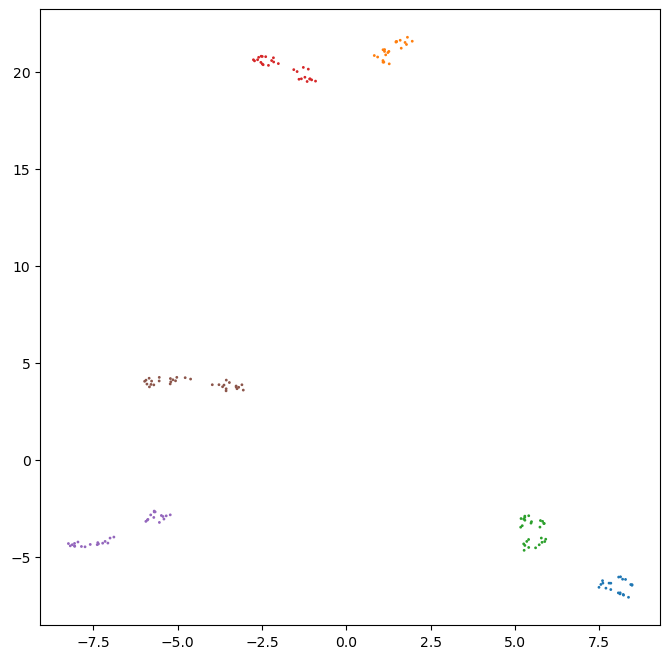

In [374]:

pipe = Pipeline([
    ('norm', StandardScaler()),
    ('proj', UMAP(random_state=1234567890)),
    ('clu', DBSCAN(eps=2.0))
])

cluster = pipe.fit_predict(X.assign(objective=y))
tradeoff_lattice(pipe['proj'].embedding_, cluster)

In [345]:
networkx

NameError: name 'keys' is not defined